In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
import lightgbm as lgb
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings('ignore')

In [2]:
# ==========================================
# 1. 원천(Raw) 데이터 로드 (기존 병합본 폐기)
# ==========================================
info_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_customer_info.csv')
finance_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_finance_profile.csv')
trans_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_transaction_history.csv')
targets_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train_targets.csv')

In [3]:
# ==========================================
# 2. 거래 내역에서 '단기 이탈 징후'만 정밀 추출
# ==========================================
print("▶️ 거래 내역에서 최근 1개월 모멘텀 추출 중...")
trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])
base_date = pd.to_datetime('2023-12-31')

# 전체 기간 월평균 거래 건수
total_freq = trans_df.groupby('customer_id')['trans_id'].count().reset_index(name='total_trans_count')

# 최근 1개월(30일) 거래 건수
recent_30d = base_date - pd.Timedelta(days=30)
recent_df = trans_df[trans_df['trans_date'] >= recent_30d]
recent_freq = recent_df.groupby('customer_id')['trans_id'].count().reset_index(name='recent_1m_count')

▶️ 거래 내역에서 최근 1개월 모멘텀 추출 중...


In [5]:
# ==========================================
# 3. 데이터 조립 및 [수정] tenure_days 직접 계산
# ==========================================
print("▶️ 이탈 예측을 위한 핵심 피처 조립 중...")

# 🚨 [수정된 부분] join_date를 활용해 가입일수(tenure_days) 생성
base_date = pd.to_datetime('2023-12-31')
info_df['join_date'] = pd.to_datetime(info_df['join_date'])
info_df['tenure_days'] = (base_date - info_df['join_date']).dt.days

# 만약 오늘 가입해서 tenure_days가 0인 고객이 있다면 에러(0으로 나누기)가 나므로 1로 바꿔줌
info_df['tenure_days'] = info_df['tenure_days'].replace(0, 1)

# 원본에서 차례대로 붙입니다. (이제 info_df에 tenure_days가 생겼습니다!)
df = info_df.merge(finance_df, on='customer_id', how='left')
df = df.merge(total_freq, on='customer_id', how='left')
df = df.merge(recent_freq, on='customer_id', how='left').fillna({'recent_1m_count': 0})
df = df.merge(targets_df[['customer_id', 'target_churn']], on='customer_id', how='left')

# 🚨 이탈 타겟용 킬러 피처 3개 생성 (이후 코드 동일)
df['avg_monthly_count'] = df['total_trans_count'] / (df['tenure_days'] / 30)
df['activity_drop_ratio'] = df['recent_1m_count'] / (df['avg_monthly_count'] + 1e-6)

df['wallet_share_shift'] = df['recent_1m_count'] / (df['total_deposit_balance'] + 1)
df['credit_risk_flag'] = np.where((df['fin_overdue_days'] > 0) | (df['credit_score'] < 600), 1, 0)

▶️ 이탈 예측을 위한 핵심 피처 조립 중...


In [6]:
# ==========================================
# 4. 범주형 변수 LightGBM 네이티브 처리
# ==========================================
cat_cols = ['gender', 'region_code', 'prefer_category', 'income_group']
for col in cat_cols:
    df[col] = df[col].astype('category')

# ==========================================

In [9]:
# ==========================================
# 5. 불균형 대응 층화 추출 (Stratified Split)
# ==========================================
X = df.drop(columns=['customer_id', 'target_churn', 'join_date'])
y = df['target_churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # 🚨 10% 비율 강제 유지
)

In [17]:
# ==========================================
# 6. 불균형 대응 모델링 (scale_pos_weight)
# ==========================================
print("▶️ 불균형 데이터에 맞춘 LightGBM 학습 시작...")

# 🚨 이탈(1) 데이터의 가중치를 계산 (대략 9배)
imbalance_ratio = (len(y_train) - y_train.sum()) / y_train.sum()

clf = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.001,
    scale_pos_weight=imbalance_ratio,  # 🔥 여기서 불균형을 타파합니다!
    verbose=-1
)

clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50)])

▶️ 불균형 데이터에 맞춘 LightGBM 학습 시작...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[155]	valid_0's binary_logloss: 0.306986


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.001
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [18]:
# ==========================================
# 7. 성능 평가 (ROC-AUC 및 PR-AUC)
# ==========================================
val_preds = clf.predict_proba(X_val)[:, 1]

# 일반적인 대회 평가 지표 (ROC-AUC)
roc_auc = roc_auc_score(y_val, val_preds)

# 불균형 데이터에서 진짜 실력을 보여주는 지표 (PR-AUC)
precision, recall, _ = precision_recall_curve(y_val, val_preds)
pr_auc = auc(recall, precision)

print("\n" + "="*50)
print(f"✅ 일반 ROC-AUC Score: {roc_auc:.4f}")
print(f"🔥 불균형 킬러 PR-AUC Score: {pr_auc:.4f} (이 수치가 높아야 진짜 성능입니다)")
print("="*50)


✅ 일반 ROC-AUC Score: 0.7824
🔥 불균형 킬러 PR-AUC Score: 0.4076 (이 수치가 높아야 진짜 성능입니다)


🔍 모델 예측 결과 심층 분석을 시작합니다...

🚨 [분석 필수] 모델이 완벽하게 속아넘어간 워스트 케이스 Top 10
-> 실제로는 이탈(1)했는데 확률을 0.01로 줬거나, 안 나갔는데(0) 0.99로 예측한 애들입니다.


,Actual_Churn,Predicted_Prob,Predicted_Class,Error_Gap,age,gender,region_code,is_married,prefer_category,income_group,...,card_cash_service_amt,card_loan_amt,fin_overdue_days,fin_asset_trend_score,total_trans_count,recent_1m_count,avg_monthly_count,activity_drop_ratio,wallet_share_shift,credit_risk_flag
43760,1,0.101923,0,0.898077,23,M,R05,1,Home,G2,...,0,0,0,-0.163315,19,4.0,0.699387,5.719290,1.011480e-04,0
2091,1,0.103796,0,0.896204,47,F,R04,0,Beauty,G2,...,88703,0,0,-0.744734,17,4.0,0.408000,9.803898,4.368302e-07,0
25269,1,0.104390,0,0.895610,26,M,R06,0,Fashion,G4,...,0,10007,0,0.206888,17,1.0,0.810811,1.233332,6.884776e-06,0
7453,1,0.104390,0,0.895610,38,M,R07,1,Home,G2,...,0,0,0,1.146738,27,4.0,1.221719,3.274071,1.858322e-05,0
41120,1,0.104413,0,0.895587,42,M,R02,1,Grocery,G5,...,0,0,2,0.647558,13,2.0,0.555556,3.599994,9.820553e-08,1


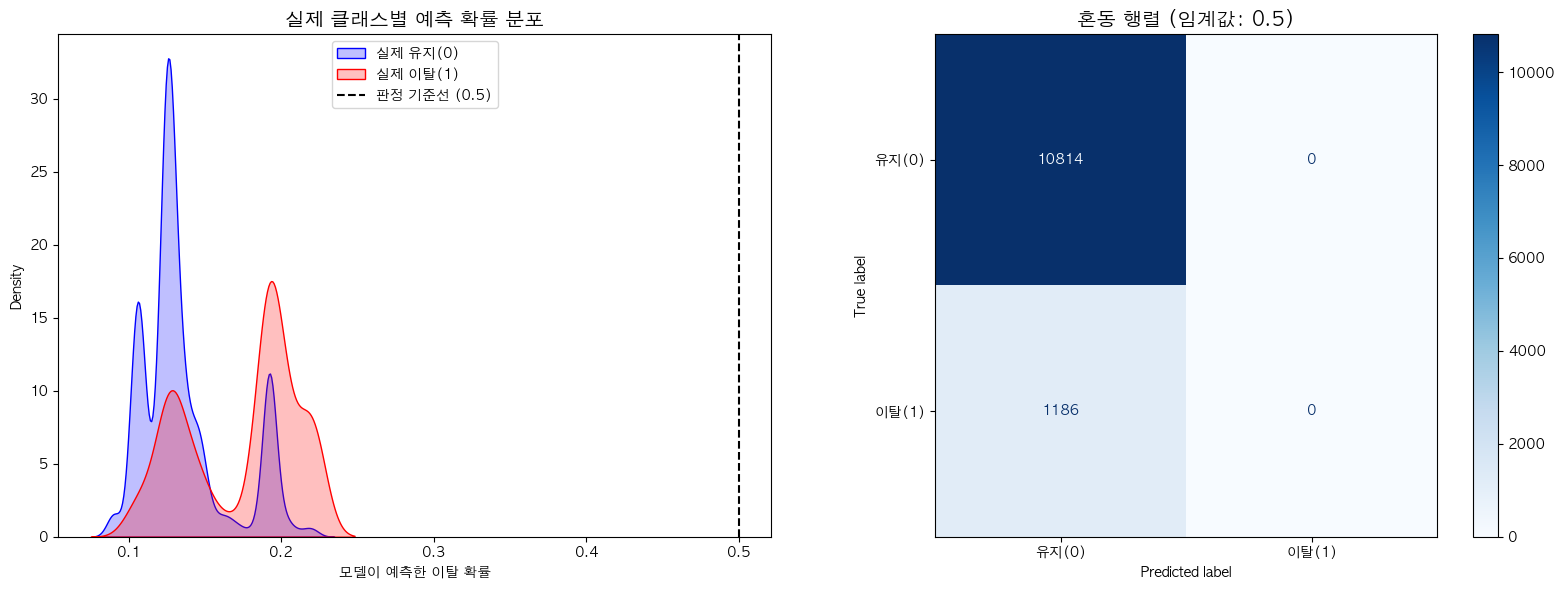

In [20]:
print("🔍 모델 예측 결과 심층 분석을 시작합니다...\n")

# ==========================================
# 1. 눈으로 직접 확인하는 비교 데이터프레임 만들기
# ==========================================
# 실제값과 모델이 예측한 확률값을 하나의 표로 묶습니다.
results_df = pd.DataFrame({
    'Actual_Churn': y_val,             # 실제 정답 (0:유지, 1:이탈)
    'Predicted_Prob': val_preds        # 모델이 예측한 이탈 확률 (0.0 ~ 1.0)
})

# 임계값(Threshold) 설정: 기본적으로 확률이 0.5 이상이면 이탈(1)로 판정합니다.
THRESHOLD = 0.5
results_df['Predicted_Class'] = (results_df['Predicted_Prob'] >= THRESHOLD).astype(int)

# 🚨 핵심: 예측과 실제의 '차이(Error)' 계산
# 1에 가까울수록 모델이 완벽하게 헛짚었다는 뜻입니다.
results_df['Error_Gap'] = abs(results_df['Actual_Churn'] - results_df['Predicted_Prob'])

# ==========================================
# 2. 모델이 가장 심하게 틀린 워스트 케이스 Top 10
# ==========================================
print("🚨 [분석 필수] 모델이 완벽하게 속아넘어간 워스트 케이스 Top 10")
print("-> 실제로는 이탈(1)했는데 확률을 0.01로 줬거나, 안 나갔는데(0) 0.99로 예측한 애들입니다.")
worst_cases = results_df.sort_values(by='Error_Gap', ascending=False).head(10)
# 인덱스가 customer_id로 되어 있다면, 해당 고객의 원본 피처(X_val)를 같이 볼 수 있게 결합합니다.
worst_cases_with_features = worst_cases.join(X_val) 
display(worst_cases_with_features.head())

# ==========================================
# 3. 오차 분석 시각화 (분포도 및 혼동 행렬)
# ==========================================
# 한글 폰트 깨짐 방지 (맥OS 기준, 윈도우는 'Malgun Gothic'으로 변경)
plt.rcParams['font.family'] = 'AppleGothic' 
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [그래프 1] 예측 확률 분포도 (Density Plot)
# 모델이 실제 0인 사람과 1인 사람을 확률적으로 얼마나 잘 갈라놓았는지 봅니다.
sns.kdeplot(data=results_df[results_df['Actual_Churn']==0], x='Predicted_Prob', fill=True, color='blue', label='실제 유지(0)', ax=axes[0])
sns.kdeplot(data=results_df[results_df['Actual_Churn']==1], x='Predicted_Prob', fill=True, color='red', label='실제 이탈(1)', ax=axes[0])
axes[0].axvline(THRESHOLD, color='black', linestyle='--', label=f'판정 기준선 ({THRESHOLD})')
axes[0].set_title('실제 클래스별 예측 확률 분포', fontsize=14)
axes[0].set_xlabel('모델이 예측한 이탈 확률')
axes[0].legend()

# [그래프 2] 혼동 행렬 (Confusion Matrix)
# 예측값과 실제값의 차이를 4가지 영역(TP, FP, TN, FN)으로 나눠서 봅니다.
cm = confusion_matrix(results_df['Actual_Churn'], results_df['Predicted_Class'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['유지(0)', '이탈(1)'])
disp.plot(cmap='Blues', ax=axes[1], values_format='d')
axes[1].set_title(f'혼동 행렬 (임계값: {THRESHOLD})', fontsize=14)

plt.tight_layout()
plt.show()

🔍 모델의 판단 기준(Feature Importance)을 분석합니다...



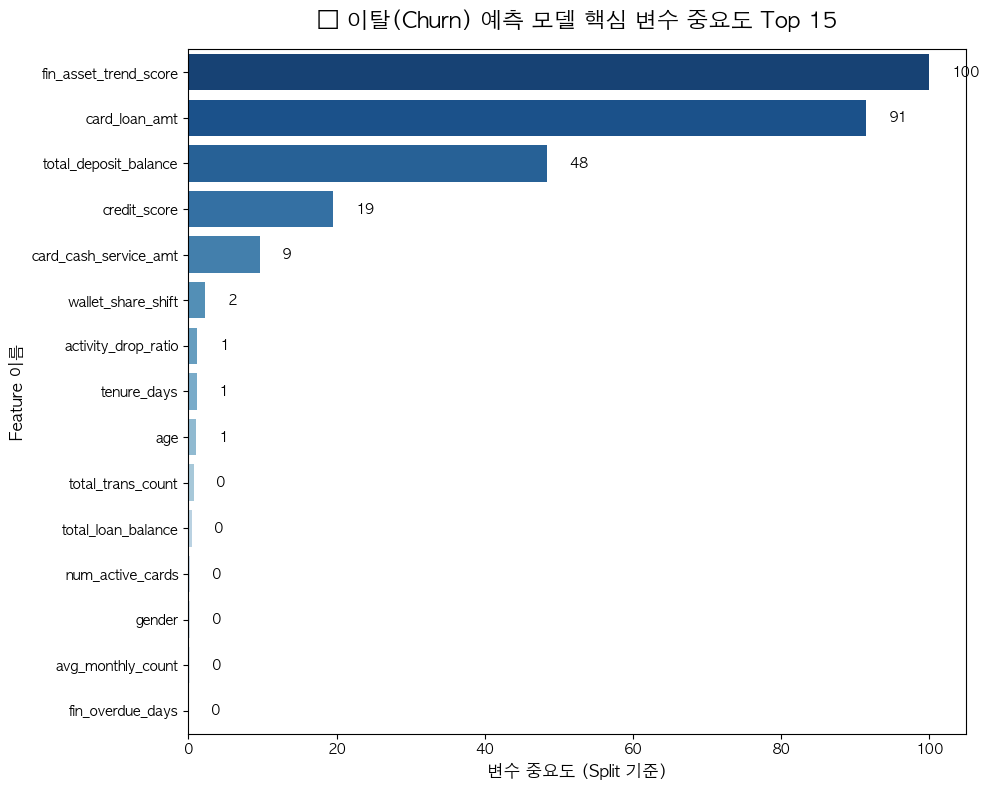

🏆 [Top 10] 이탈 예측을 결정지은 핵심 변수들:


,Feature,Importance
0,fin_asset_trend_score,100.000000
1,card_loan_amt,91.487376
2,total_deposit_balance,48.355443
3,credit_score,19.526426
4,card_cash_service_amt,9.612339
5,wallet_share_shift,2.305924
6,activity_drop_ratio,1.167044
7,tenure_days,1.113798
8,age,1.056803
9,total_trans_count,0.760495


In [15]:
print("🔍 모델의 판단 기준(Feature Importance)을 분석합니다...\n")

# ==========================================
# 1. 피처 중요도 추출 (🚨 Split 대신 Gain 사용!)
# ==========================================
# importance_type='gain' : 해당 변수로 분기했을 때 오차를 얼마나 획기적으로 줄였는지(기여도)
feature_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': clf.booster_.feature_importance(importance_type='gain') 
})

# 중요도가 높은 순으로 정렬 (보기 좋게 정규화)
feature_imp['Importance'] = 100 * (feature_imp['Importance'] / feature_imp['Importance'].max())
feature_imp = feature_imp.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# ==========================================
# 2. 발표/보고용 깔끔한 시각화 (Top 15)
# ==========================================
# 한글 폰트 설정 (맥: AppleGothic, 윈도우: Malgun Gothic)
plt.rcParams['font.family'] = 'AppleGothic'  # 윈도우 사용자는 'Malgun Gothic'으로 변경해주세요!
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 8))
# 상위 15개 변수만 뽑아서 그립니다. (색상 테마는 신뢰감을 주는 푸른계열)
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(15), palette='Blues_r')

plt.title('🔥 이탈(Churn) 예측 모델 핵심 변수 중요도 Top 15', fontsize=16, pad=15)
plt.xlabel('변수 중요도 (Split 기준)', fontsize=12)
plt.ylabel('Feature 이름', fontsize=12)

# 막대 끝에 실제 수치 적어주기
for i, v in enumerate(feature_imp['Importance'].head(15)):
    plt.text(v + 3, i + 0.1, str(int(v)), color='black', fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================
# 3. 텍스트로도 상위 10개 출력 (복사-붙여넣기 용)
# ==========================================
print("🏆 [Top 10] 이탈 예측을 결정지은 핵심 변수들:")
display(feature_imp.head(10))